<a href="https://colab.research.google.com/github/sulthanalihsan/data-science-2026/blob/main/Pertemuan4_Muhamad_Sulthan_Al_Ihsan_250401020154_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# =============================================
# PERTEMUAN 4: STATISTIKA DASAR & ANALISIS DATA
# Nama Mahasiswa: Muhammad Sulthan Al Ihsan
# NIM: 250401020154
# =============================================

# =============================================
# LANGKAH 0: Import Semua Library Yang Diperlukan
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!


In [5]:
# =============================================
# Load & Inspect Dataset
# =============================================
df = sns.load_dataset('iris')

print('\nShape Dataset:', df.shape)
print('\ndtypes:')
print(df.dtypes)
print('\nHead (5 baris pertama):')
print(df.head())
print('\nDescribe (Statistik Ringkasan):')
print(df.describe().round(3))


Shape Dataset: (150, 5)

dtypes:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Head (5 baris pertama):
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Describe (Statistik Ringkasan):
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.0

In [6]:
# =============================================
# Statistik Deskriptif Lengkap
# =============================================
print("\n" + "="*60)
print("STATISTIK DESKRIPITF LENGKAP")
print("="*60)

for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'   Mean     : {col.mean():.3f}')
    print(f'   Median   : {col.median():.3f}')
    print(f'   Std Dev  : {col.std():.3f}')
    print(f'   Varians  : {col.var():.3f}')
    print(f'   Skewness : {col.skew():.3f}')
    print(f'   Kurtosis : {col.kurt():.3f}')


STATISTIK DESKRIPITF LENGKAP

=== sepal_length ===
   Mean     : 5.843
   Median   : 5.800
   Std Dev  : 0.828
   Varians  : 0.686
   Skewness : 0.315
   Kurtosis : -0.552

=== sepal_width ===
   Mean     : 3.057
   Median   : 3.000
   Std Dev  : 0.436
   Varians  : 0.190
   Skewness : 0.319
   Kurtosis : 0.228

=== petal_length ===
   Mean     : 3.758
   Median   : 4.350
   Std Dev  : 1.765
   Varians  : 3.116
   Skewness : -0.275
   Kurtosis : -1.402

=== petal_width ===
   Mean     : 1.199
   Median   : 1.300
   Std Dev  : 0.762
   Varians  : 0.581
   Skewness : -0.103
   Kurtosis : -1.341



ANALISIS DISTRIBUSI - Sepal Length


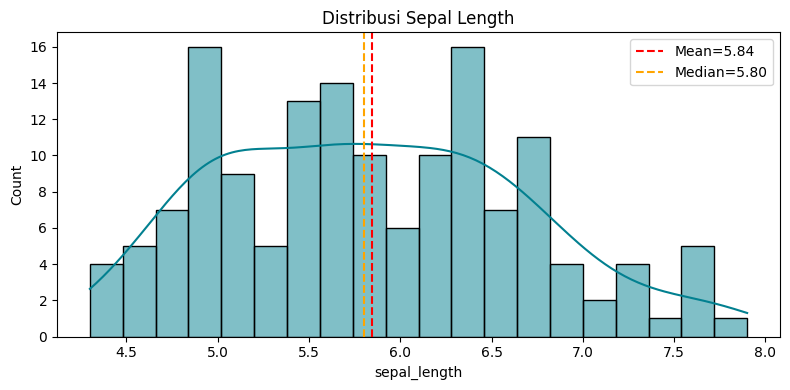

Jenis Distribusi: Simetris (Normal) (Skewness=0.315)


In [7]:
# =============================================
# Analisis Distribusi (Histogram + KDE)
# =============================================
print("\n" + "="*60)
print("ANALISIS DISTRIBUSI - Sepal Length")
print("="*60)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red', linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange', linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length')
ax.legend()
plt.tight_layout()
plt.show()

# Identifikasi distribusi berdasarkan skewness
skew_val = df['sepal_length'].skew()
if abs(skew_val) < 0.5:
    dist_type = "Simetris (Normal)"
elif skew_val > 0.5:
    dist_type = "Right-Skewed (Miring Kanan)"
else:
    dist_type = "Left-Skewed (Miring Kiri)"

print(f"Jenis Distribusi: {dist_type} (Skewness={skew_val:.3f})")


BOX PLOT PER SPESIES


/tmp/ipykernel_4715/3414613970.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
/tmp/ipykernel_4715/3414613970.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])


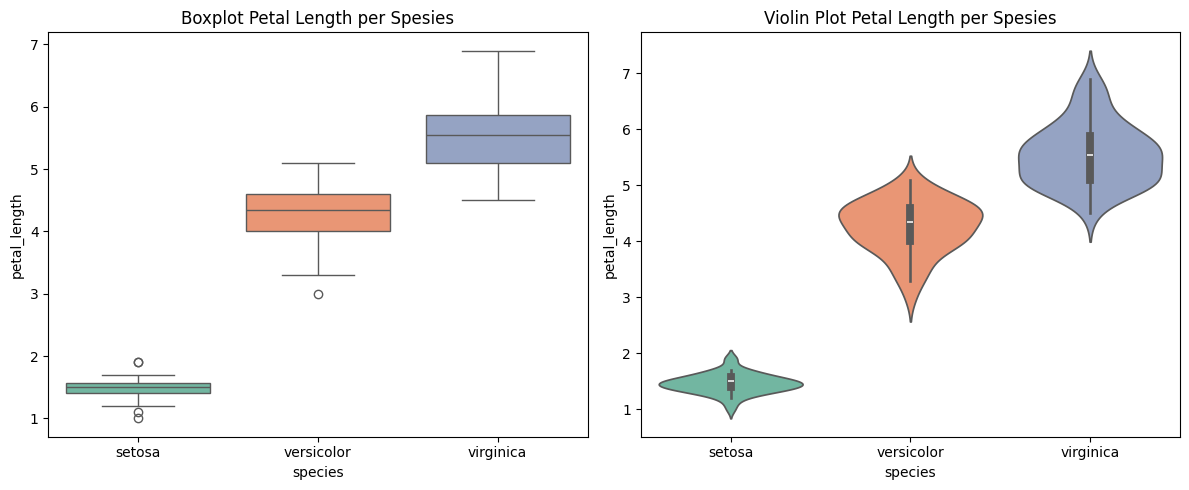


Ringkasan Petal Length per Spesies:
      species  max  min    std
0      setosa  1.9  1.0  0.174
1  versicolor  5.1  3.0  0.470
2   virginica  6.9  4.5  0.552

pesies dengan nilai MAKSIMAL: virginica (6.900)
Spesies dengan nilai MINIMAL: setosa (1.000)
Spesies dengan persebaran PALING BANYAK: virginica (Std=0.552)


In [9]:
# =============================================
# Boxplot per Spesies
# =============================================
print("\n" + "="*60)
print("BOX PLOT PER SPESIES")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length per Spesies')

# Violin Plot
sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length per Spesies')

plt.tight_layout()
plt.show()

# Identifikasi spesies dengan nilai terbesar, terkecil, dan paling tersebar
species_summary = df.groupby('species')['petal_length'].agg(['max', 'min', 'std']).reset_index()
print("\nRingkasan Petal Length per Spesies:")
print(species_summary.round(3))

max_species = species_summary.loc[species_summary['max'].idxmax()]
min_species = species_summary.loc[species_summary['min'].idxmin()]
spread_species = species_summary.loc[species_summary['std'].idxmax()]

print(f"\npesies dengan nilai MAKSIMAL: {max_species['species']} ({max_species['max']:.3f})")
print(f"Spesies dengan nilai MINIMAL: {min_species['species']} ({min_species['min']:.3f})")
print(f"Spesies dengan persebaran PALING BANYAK: {spread_species['species']} (Std={spread_species['std']:.3f})")


In [11]:
# =============================================
# Matriks Korelasi Pearson
# =============================================
print("\n" + "="*60)
print("MATRIKS KORELASI PEARSON")
print("="*60)

corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

# Cari pasangan tertinggi dan terendah
corr_masked = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1) == False)
max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()

print(f"\nKorelasi Tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}")
print(f"Korelasi Terendah: {min_pair} = {corr.loc[min_pair]:.3f}")


MATRIKS KORELASI PEARSON
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi Tertinggi: ('sepal_length', 'sepal_length') = 1.000
Korelasi Terendah: ('petal_length', 'sepal_width') = -0.428



SCATTER PLOT & HEATMAP


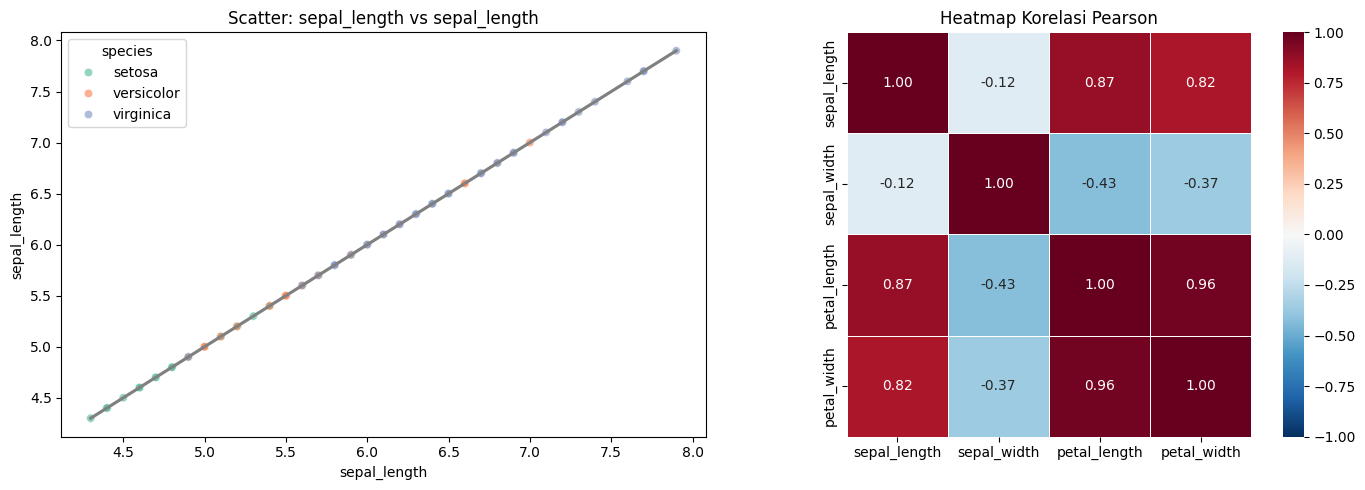

In [12]:
# =============================================
# Scatter Plot & Heatmap
# =============================================
print("\n" + "="*60)
print("SCATTER PLOT & HEATMAP")
print("="*60)

# Pilih pasangan berkorelasi tertinggi
x_col = max_pair[0]
y_col = max_pair[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Plot dengan Regresi Line
sns.scatterplot(data=df, x=x_col, y=y_col, hue='species', palette='Set2', ax=axes[0], alpha=0.7)
sns.regplot(data=df, x=x_col, y=y_col, scatter=False, color='gray', ax=axes[0])
axes[0].set_title(f'Scatter: {x_col} vs {y_col}')

# Heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor='white', ax=axes[1])
axes[1].set_title('Heatmap Korelasi Pearson')

plt.tight_layout()
plt.show()
